In [1]:
# ============================================
# 0. Imports & plotting style
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")
pd.options.display.float_format = "{:,.4f}".format

# ============================================
# 1. Helper functions
# ============================================

def annualize_from_monthly(df, date_col, value_cols, how="mean"):
    """
    Convert monthly DataFrame -> annual:
    how = 'mean' or 'max'
    Returns DataFrame with ['Year'] + aggregated columns.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df["Year"] = df[date_col].dt.year
    if how == "mean":
        agg = df.groupby("Year")[value_cols].mean().reset_index()
    elif how == "max":
        agg = df.groupby("Year")[value_cols].max().reset_index()
    else:
        raise ValueError("how must be 'mean' or 'max'")
    return agg


def load_fred_series(path, series_name):
    """
    Robust loader for FRED CSVs stored in Data/.
    Tries to find a date column (DATE or observation_date) and the series column
    by case-insensitive matching.
    """
    df = pd.read_csv(path)

    # 1) find date column
    date_candidates = [
        c for c in df.columns
        if c.lower() in ("date", "observation_date")
    ]
    if not date_candidates:
        raise KeyError(f"No date column found in {path}")
    date_col = date_candidates[0]
    df.rename(columns={date_col: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])

    # 2) find series column (case-insensitive)
    if series_name not in df.columns:
        matches = [c for c in df.columns if c.lower() == series_name.lower()]
        if matches:
            df.rename(columns={matches[0]: series_name}, inplace=True)
        else:
            raise KeyError(f"{series_name} column not found in {path}")

    return df


def scatter_with_reg(x, y, x_label, y_label, title):
    """
    Simple scatter + OLS regression line with slope / p-value in the title.
    """
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = model.predict(sm.add_constant(x_line))

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(x_line, y_line, lw=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(
        f"{title}\nSlope={model.params[1]:.3f}, p={model.pvalues[1]:.3f}"
    )
    plt.show()

    return model


def plot_with_events(x, y, label, ylabel, title, event_years=None):
    """
    Plot a time-series and (optionally) vertical lines for disruption years.

    event_years: dict like {year_int: "Label"} or None
    """
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, label=label)
    plt.ylabel(ylabel)
    plt.xlabel("Year")

    if event_years:
        for yr, txt in event_years.items():
            plt.axvline(yr, color="red", linestyle="--", alpha=0.5)
            plt.text(
                yr + 0.05, plt.ylim()[1],
                txt,
                rotation=90,
                va="top",
                ha="left",
                fontsize=8,
                color="red"
            )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Handy dictionary of major disruption years (you can tweak this)
EVENT_YEARS = {
    2008: "GFC",
    2011: "Japan EQ / Thai floods",
    2015: "US port strike",
    2020: "COVID shock",
    2021: "Post-COVID congestion / Ever Given",
    2022: "Ukraine war"
}


In [2]:

# ============================================
# 2. Load supply chain stress indices
# ============================================

# 2.1 GSCPI (NY Fed)
gscpi = pd.read_excel("Data/gscpi_data.xlsx", sheet_name="Data")
gscpi["Date"] = pd.to_datetime(gscpi["Date"])
gscpi = gscpi.sort_values("Date")
gscpi = gscpi.rename(columns={"GSCPI": "GSCPI"})  # keep name explicit

# 2.2 GSCSI / World Bank global stress index
wb = pd.read_excel("Data/Stress index tables.xlsx", sheet_name="global")

# Adjust column names if needed
wb = wb.rename(columns={
    "Departure_YearMonth": "Date",
    wb.columns[-1]: "GSCSI"  # last column is the index in your file
})

# The World Bank dates are already YYYY-MM-ish in your cleaned file
wb["Date"] = pd.to_datetime(wb["Date"], errors="coerce")
wb = wb.sort_values("Date")

In [3]:

# ============================================
# 3. Load Swiss Re standard insurance data
#    (A: Extract US “loss ratio-like” data)
# ============================================

sri = pd.read_csv("Data/swissre_insurance.csv")

# Focus: US, non-life business, manufacturing-exposed lines
us_nonlife = sri[
    (sri["Country"] == "US") &
    (sri["Business line"].isin(["STOT", "SMEDEX"]))
].copy()

# Convert Time Period to Year
us_nonlife["Year"] = us_nonlife["Time Period"].astype(int)

# ---- 3.1 Premium exposure metrics ----
exposure_mask = us_nonlife["Series.1"] == "Premium volume in USD"
growth_mask   = us_nonlife["Series.1"] == "Premium real growth"

exp = us_nonlife[exposure_mask].copy()
gr  = us_nonlife[growth_mask].copy()

exp_wide = exp.pivot_table(
    index="Year",
    columns="Business line",
    values="Observation value"
).rename(columns=lambda c: f"Premium_USD_{c}")

gr_wide = gr.pivot_table(
    index="Year",
    columns="Business line",
    values="Observation value"
).rename(columns=lambda c: f"PremiumRealGrowth_{c}")

swissre_annual = pd.concat([exp_wide, gr_wide], axis=1).reset_index()

# ---- 3.2 OPTIONAL: loss ratios if loss/claims data exist ----
# The standard insurance CSV you showed only has premium-related series.
# But this block will automatically compute loss ratios IF you later add
# a Swiss Re dataset with “loss” or “claims” in Series.1.

loss_mask = us_nonlife["Series.1"].str.contains("loss", case=False, na=False) | \
            us_nonlife["Series.1"].str.contains("claim", case=False, na=False)

if loss_mask.sum() > 0:
    losses = us_nonlife[loss_mask].copy()
    loss_wide = losses.pivot_table(
        index="Year",
        columns="Business line",
        values="Observation value"
    ).rename(columns=lambda c: f"Losses_USD_{c}")
    swissre_annual = swissre_annual.merge(loss_wide, on="Year", how="left")

    # Build loss ratios: losses / premiums
    for line in ["STOT", "SMEDEX"]:
        prem_col = f"Premium_USD_{line}"
        loss_col = f"Losses_USD_{line}"
        if prem_col in swissre_annual.columns and loss_col in swissre_annual.columns:
            swissre_annual[f"LossRatio_{line}"] = (
                swissre_annual[loss_col] / swissre_annual[prem_col]
            )
else:
    print(
        "NOTE: No loss/claims series found in Series.1; "
        "swissre_annual contains premium volume & growth only."
    )

print(swissre_annual.head())

NOTE: No loss/claims series found in Series.1; swissre_annual contains premium volume & growth only.
Business line  Year  Premium_USD_SMEDEX  Premium_USD_STOT  \
0              1991            198.3011          646.2900   
1              1992            210.4126          674.6936   
2              1993            225.7799          722.8595   
3              1994            235.1691          760.9909   
4              1995            248.7727          793.8493   

Business line  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  
0                                0.0416                 -0.0134  
1                                0.0298                  0.0131  
2                                0.0421                  0.0405  
3                                0.0152                  0.0261  
4                                0.0290                  0.0147  


In [4]:

# ============================================
# 4. Load FRED macro / manufacturing proxies
# ============================================

businv  = load_fred_series("Data/BUSINV.csv",  "BUSINV")
dgorder = load_fred_series("Data/DGORDER.csv", "DGORDER")
ipman   = load_fred_series("Data/IPMAN.csv",   "IPMAN")
ppi     = load_fred_series("Data/PPIACO.csv",  "PPIACO")

businv_ann  = annualize_from_monthly(businv,  "Date", ["BUSINV"],  how="mean")
dgorder_ann = annualize_from_monthly(dgorder, "Date", ["DGORDER"], how="mean")

ipman["IPMAN_YoY"] = ipman["IPMAN"].pct_change(12) * 100
ipman_ann = annualize_from_monthly(ipman, "Date", ["IPMAN", "IPMAN_YoY"], how="mean")

ppi["PPI_YoY"] = ppi["PPIACO"].pct_change(12) * 100
ppi_ann = annualize_from_monthly(ppi, "Date", ["PPIACO", "PPI_YoY"], how="mean")

In [5]:

# ============================================
# 5. Load MSCI sector indices (Auto & Materials)
# ============================================

msci_auto = pd.read_excel("Data/MSCI_Auto.xls")
msci_mat  = pd.read_excel("Data/MSCI_Materials.xls")

# Assume first two columns are Date, Index
msci_auto = msci_auto.rename(columns={
    msci_auto.columns[0]: "Date",
    msci_auto.columns[1]: "MSCI_Auto"
})
msci_mat = msci_mat.rename(columns={
    msci_mat.columns[0]: "Date",
    msci_mat.columns[1]: "MSCI_Materials"
})

msci_auto["Date"] = pd.to_datetime(msci_auto["Date"])
msci_mat["Date"]  = pd.to_datetime(msci_mat["Date"])

msci_auto_ann = annualize_from_monthly(msci_auto, "Date", ["MSCI_Auto"], how="mean")
msci_mat_ann  = annualize_from_monthly(msci_mat,  "Date", ["MSCI_Materials"], how="mean")

msci_auto_ann["MSCI_Auto_Return"] = msci_auto_ann["MSCI_Auto"].pct_change()
msci_mat_ann["MSCI_Materials_Return"] = msci_mat_ann["MSCI_Materials"].pct_change()

In [6]:

# ============================================
# 6. Annualize stress indices & merge everything
# ============================================

gscpi_ann      = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="mean")
gscpi_ann_max  = annualize_from_monthly(gscpi, "Date", ["GSCPI"], how="max")
gscpi_ann_max  = gscpi_ann_max.rename(columns={"GSCPI": "GSCPI_max"})
gscpi_ann      = gscpi_ann.merge(gscpi_ann_max, on="Year", how="left")

gscsi_ann      = annualize_from_monthly(wb, "Date", ["GSCSI"], how="mean")
gscsi_ann_max  = annualize_from_monthly(wb, "Date", ["GSCSI"], how="max")
gscsi_ann_max  = gscsi_ann_max.rename(columns={"GSCSI": "GSCSI_max"})
gscsi_ann      = gscsi_ann.merge(gscsi_ann_max, on="Year", how="left")

# Start master DataFrame with stress indices
df = gscpi_ann.merge(gscsi_ann, on="Year", how="inner")

# Merge Swiss Re insurance metrics
df = df.merge(swissre_annual, on="Year", how="inner")

# Merge FRED macro variables
for macro_df in [businv_ann, dgorder_ann, ipman_ann, ppi_ann]:
    df = df.merge(macro_df, on="Year", how="left")

# Merge MSCI sectors
for eq_df in [msci_auto_ann, msci_mat_ann]:
    df = df.merge(eq_df, on="Year", how="left")

# Restrict to 2000+ and drop very recent partial years if needed
df = df[df["Year"] >= 2000].copy()

# Lag stress indices so that stress in year t affects insurance in t or t+1
df["GSCPI_lag1"] = df["GSCPI"].shift(1)
df["GSCSI_lag1"] = df["GSCSI"].shift(1)

df_model = df.dropna().reset_index(drop=True)
print(df_model.head())


   Year   GSCPI  GSCPI_max          GSCSI      GSCSI_max  Premium_USD_SMEDEX  \
0  2017  0.3084     0.8131   257,744.0674   471,772.8776            993.8985   
1  2018  0.4445     0.5902   221,054.7853   308,834.0508          1,051.2650   
2  2019 -0.0394     0.5134   293,525.5654   419,825.0926          1,113.1153   
3  2020  1.6567     3.3597   614,624.5983   804,725.1310          1,200.8624   
4  2021  3.0839     4.4628 1,285,982.8979 1,795,985.5425          1,290.6321   

   Premium_USD_STOT  PremiumRealGrowth_SMEDEX  PremiumRealGrowth_STOT  \
0        2,181.9131                    0.0329                  0.0160   
1        2,308.8598                    0.0325                  0.0330   
2        2,424.7901                    0.0400                  0.0315   
3        2,530.0488                    0.0655                  0.0305   
4        2,739.9351                    0.0266                  0.0345   

          BUSINV  ...    IPMAN  IPMAN_YoY   PPIACO  PPI_YoY  MSCI_Auto  \
0 1,87

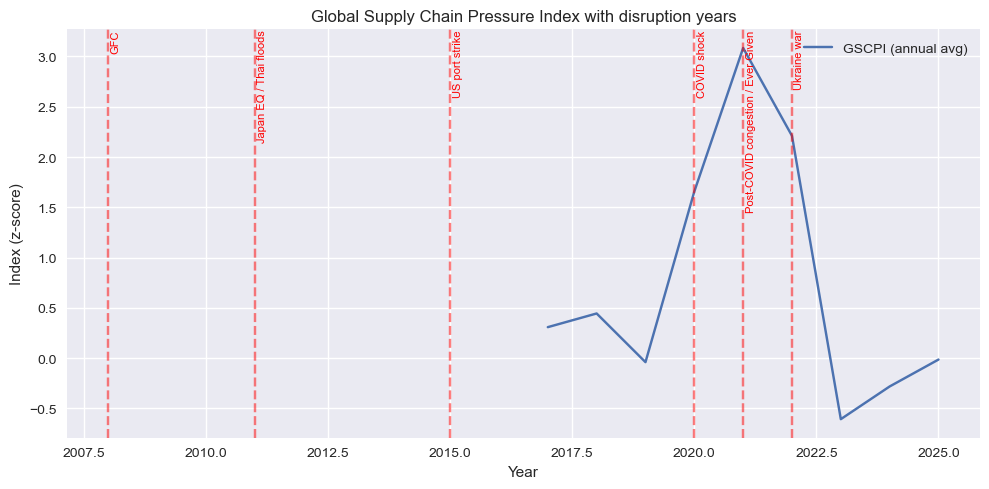

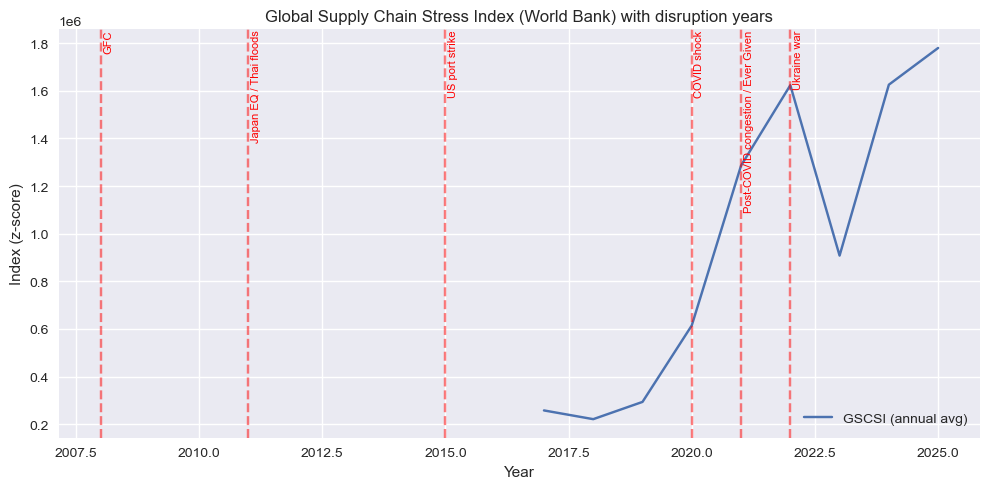

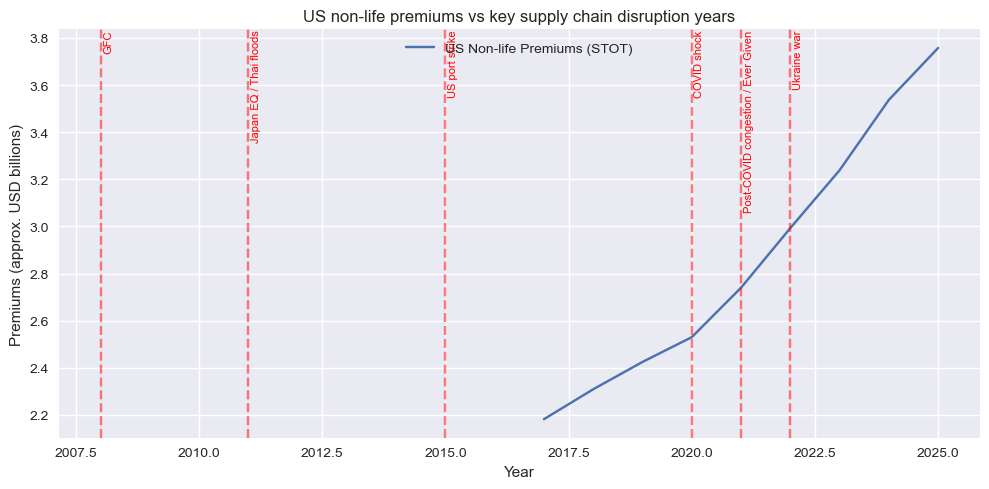

In [7]:
# ============================================
# 7. (B) Event-annotated charts for disruption years
# ============================================

# 7.1 Stress indices with vertical lines for big events
plot_with_events(
    x=df_model["Year"],
    y=df_model["GSCPI"],
    label="GSCPI (annual avg)",
    ylabel="Index (z-score)",
    title="Global Supply Chain Pressure Index with disruption years",
    event_years=EVENT_YEARS
)

plot_with_events(
    x=df_model["Year"],
    y=df_model["GSCSI"],
    label="GSCSI (annual avg)",
    ylabel="Index (z-score)",
    title="Global Supply Chain Stress Index (World Bank) with disruption years",
    event_years=EVENT_YEARS
)

# 7.2 US premium exposure vs events
plot_with_events(
    x=df_model["Year"],
    y=df_model["Premium_USD_STOT"] / 1e3,   # billions if values are in millions
    label="US Non-life Premiums (STOT)",
    ylabel="Premiums (approx. USD billions)",
    title="US non-life premiums vs key supply chain disruption years",
    event_years=EVENT_YEARS
)

# If you actually have loss ratios, you can also annotate them:
for col in ["LossRatio_STOT", "LossRatio_SMEDEX"]:
    if col in df_model.columns:
        plot_with_events(
            x=df_model["Year"],
            y=df_model[col],
            label=col,
            ylabel="Loss ratio",
            title=f"{col} vs disruption years",
            event_years=EVENT_YEARS
        )

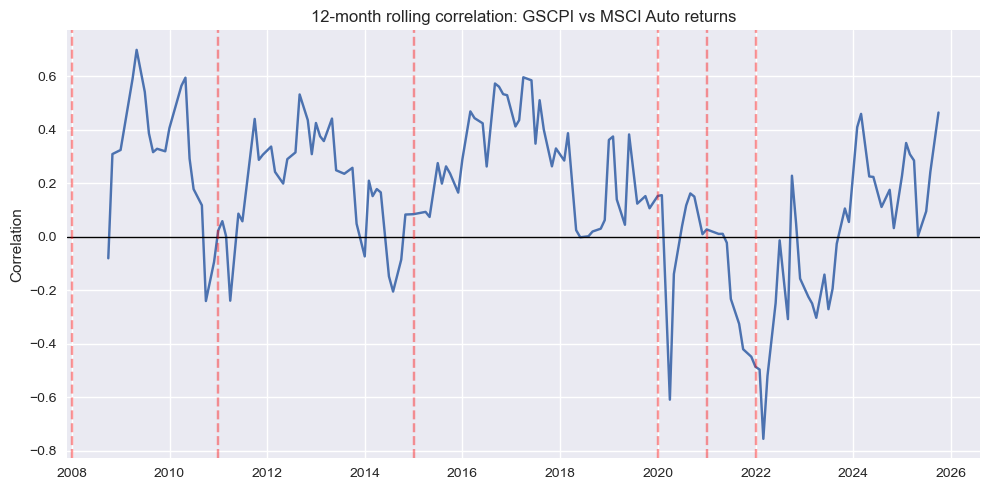

Rolling correlation summary:
  Mean corr (full sample): 0.153
  Min corr: -0.756
  Max corr: 0.698

Around COVID (2019–2021):
  Mean corr: -0.021
  Min corr: -0.61
  Max corr: 0.382


In [8]:

# ============================================
# 8. (C) Rolling correlations at monthly frequency
# ============================================

# Monthly join of GSCPI and MSCI Auto
monthly = (
    gscpi[["Date", "GSCPI"]]
    .merge(msci_auto[["Date", "MSCI_Auto"]], on="Date", how="inner")
    .sort_values("Date")
    .copy()
)
monthly["MSCI_Auto_Return"] = monthly["MSCI_Auto"].pct_change() * 100
monthly["GSCPI_3m_roll"]    = monthly["GSCPI"].rolling(3).mean()

# 12-month rolling correlation between stress and auto returns
monthly["Corr_12m"] = (
    monthly["GSCPI"].rolling(12).corr(monthly["MSCI_Auto_Return"])
)

plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Corr_12m"])
plt.axhline(0, color="black", lw=1)
# Add vertical lines for same event years
for yr, label in EVENT_YEARS.items():
    plt.axvline(pd.Timestamp(f"{yr}-01-01"), color="red", linestyle="--", alpha=0.4)
plt.title("12-month rolling correlation: GSCPI vs MSCI Auto returns")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

# Quick textual summary for you inside the notebook:
corr_window = monthly.dropna(subset=["Corr_12m"])
print("Rolling correlation summary:")
print("  Mean corr (full sample):", round(corr_window["Corr_12m"].mean(), 3))
print("  Min corr:", round(corr_window["Corr_12m"].min(), 3))
print("  Max corr:", round(corr_window["Corr_12m"].max(), 3))

# You can also eyeball specific event windows, e.g. +/- 1 year around 2020:
covid_window = corr_window[
    (corr_window["Date"] >= "2019-01-01") &
    (corr_window["Date"] <= "2021-12-31")
]
print("\nAround COVID (2019–2021):")
print("  Mean corr:", round(covid_window["Corr_12m"].mean(), 3))
print("  Min corr:", round(covid_window["Corr_12m"].min(), 3))
print("  Max corr:", round(covid_window["Corr_12m"].max(), 3))
